<a href="https://colab.research.google.com/github/A1ief/KLASIFIKASI-BATIK-MENGGUNAKAN-RANDOM-FOREST/blob/main/2318045MohammadAlifAlbannaCintraBatikMetodeRandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔍 MENGECEK FOLDER DATASET
✅ Folder ditemukan: /content/drive/MyDrive/SMT6/COMPUTER VISION/UTS/train

📁 Folder kelas yang tersedia:
   - NTB_Lumbung: 32 gambar
   - DKI_Ondel_Ondel: 32 gambar
   - Jawa_Barat_Megamendung: 32 gambar
   - Sulawesi_Selatan_Lontara: 32 gambar
   - Yogyakarta_Kawung: 32 gambar
   - Papua_Cendrawasih: 32 gambar
   - Papua_Asmat: 32 gambar
   - Lampung_Gajah: 32 gambar
   - Jawa_Timur_Pring: 32 gambar
   - Madura_Mataketeran: 32 gambar
   - Kalimantan_Dayak: 32 gambar
   - Solo_Parang: 32 gambar
   - Sumatera_Barat_Rumah_Minang: 32 gambar
   - Bali_Merak: 32 gambar
   - Sumatera_Utara_Boraspati: 32 gambar
   - Bali_Barong: 32 gambar
   - Maluku_Pala: 32 gambar
   - Yogyakarta_Parang: 32 gambar
   - Aceh_Pintu_Aceh: 32 gambar
   - Papua_Tifa: 32 gambar

✅ Kelas yang akan diproses: 6 kelas

📸 MENGAMBIL 100 GAMBAR ACAK (MERATA PER KELAS)
Target: 16 gambar per kelas
(Plus 4 kelas akan mendapat 1 gambar tambahan)

📁 Aceh_Pintu_Aceh: 32 gambar tersedia

📁 Bali_Barong

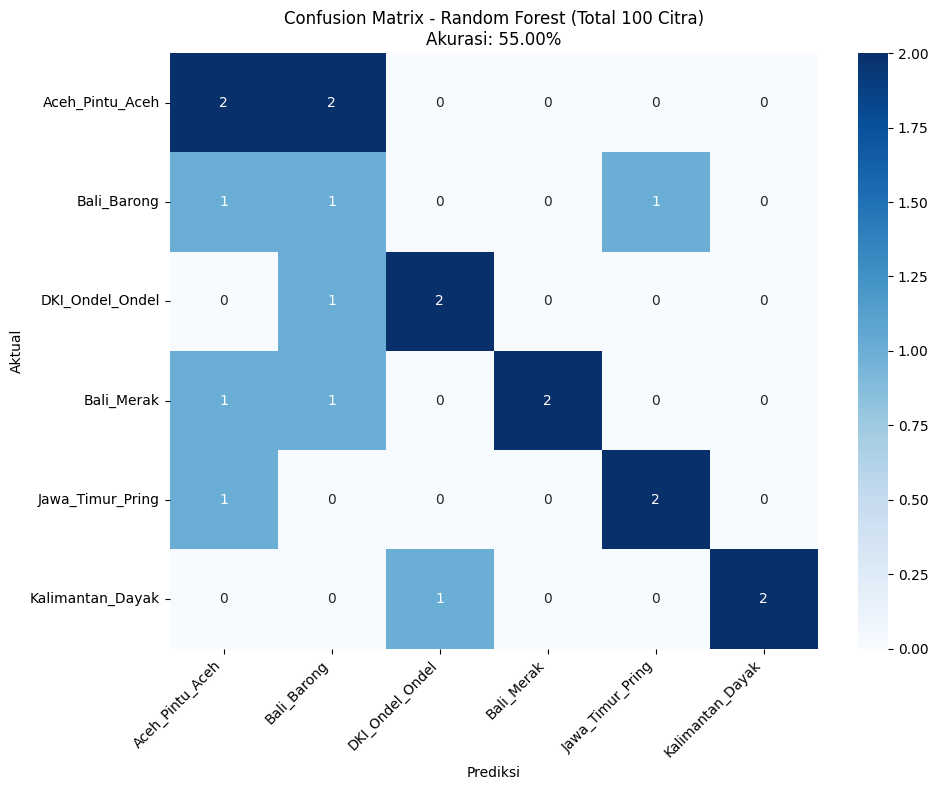


🔍 CONTOH PREDIKSI (Test Set)
✗ Prediksi: Bali_Barong               | Aktual: Aceh_Pintu_Aceh          
✗ Prediksi: Aceh_Pintu_Aceh           | Aktual: Jawa_Timur_Pring         
✓ Prediksi: Bali_Barong               | Aktual: Bali_Barong              
✓ Prediksi: Aceh_Pintu_Aceh           | Aktual: Aceh_Pintu_Aceh          
✗ Prediksi: Bali_Barong               | Aktual: DKI_Ondel_Ondel          
✗ Prediksi: DKI_Ondel_Ondel           | Aktual: Kalimantan_Dayak         
✗ Prediksi: Bali_Barong               | Aktual: Aceh_Pintu_Aceh          
✗ Prediksi: Aceh_Pintu_Aceh           | Aktual: Bali_Merak               
✓ Prediksi: Jawa_Timur_Pring          | Aktual: Jawa_Timur_Pring         
✓ Prediksi: Aceh_Pintu_Aceh           | Aktual: Aceh_Pintu_Aceh          

⭐ TOP 10 FITUR PALING PENTING
1. Std_R: 0.0747
2. Hist_R_bin0: 0.0412
3. Hist_R_bin1: 0.0409
4. Std_G: 0.0385
5. Hist_G_bin0: 0.0364
6. Hist_B_bin0: 0.0360
7. Hist_R_bin4: 0.0353
8. Hist_R_bin8: 0.0352
9. Hist_R_bin2: 0.0347
10. 

In [3]:
"""
PROYEK KLASIFIKASI BATIK DENGAN RANDOM FOREST
- Mengambil TOTAL 100 citra (bukan 100 per kelas)
- Ekstraksi fitur warna
- Klasifikasi dengan Random Forest
- OUTPUT: CSV dan Excel file
"""

import os
import numpy as np
import cv2
import random
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. SETUP
# ============================================
DATASET_PATH = "/content/drive/MyDrive/SMT6/COMPUTER VISION/UTS/train"
TOTAL_IMAGES = 100  # TOTAL 100 CITRA SAJA!
IMG_SIZE = (128, 128)

# Nama kelas
CLASS_NAMES = ['Aceh_Pintu_Aceh', 'Bali_Barong', 'DKI_Ondel_Ondel',
               'Bali_Merak', 'Jawa_Timur_Pring', 'Kalimantan_Dayak', 'Maluku_pala']

# ============================================
# 2. FUNGSI EKSTRAKSI FITUR
# ============================================

def extract_features(image_path):
    """Ekstrak fitur dari gambar: Mean RGB, Std RGB, Histogram (36 fitur)"""
    img = cv2.imread(image_path)
    if img is None:
        return np.zeros(36)

    img = cv2.resize(img, IMG_SIZE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mean_rgb = np.mean(img_rgb, axis=(0, 1))
    std_rgb = np.std(img_rgb, axis=(0, 1))

    hist_features = []
    for i in range(3):
        hist = np.histogram(img_rgb[:,:,i], bins=10, range=(0, 255))[0]
        hist_features.extend(hist)

    return np.concatenate([mean_rgb, std_rgb, hist_features])

def get_feature_names():
    """Membuat nama-nama fitur (36 nama)"""
    feature_names = []

    # Mean RGB (3 fitur)
    feature_names.append('Mean_R')
    feature_names.append('Mean_G')
    feature_names.append('Mean_B')

    # Std RGB (3 fitur)
    feature_names.append('Std_R')
    feature_names.append('Std_G')
    feature_names.append('Std_B')

    # Histogram 10 bins per channel (30 fitur)
    for channel in ['R', 'G', 'B']:
        for bin_num in range(10):
            feature_names.append(f'Hist_{channel}_bin{bin_num}')

    return feature_names

# ============================================
# 3. CEK FOLDER
# ============================================
print("="*50)
print("🔍 MENGECEK FOLDER DATASET")
print("="*50)

if not os.path.exists(DATASET_PATH):
    print(f"❌ ERROR: Folder tidak ditemukan di: {DATASET_PATH}")
    exit()

print(f"✅ Folder ditemukan: {DATASET_PATH}")

# Tampilkan isi folder
print("\n📁 Folder kelas yang tersedia:")
available_classes = []
for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        print(f"   - {folder}: {count} gambar")
        available_classes.append(folder)

# Filter kelas yang tersedia
CLASS_NAMES = [c for c in CLASS_NAMES if c in available_classes]
print(f"\n✅ Kelas yang akan diproses: {len(CLASS_NAMES)} kelas")

if len(CLASS_NAMES) == 0:
    print("❌ Tidak ada kelas yang cocok!")
    exit()

# ============================================
# 4. AMBIL TOTAL 100 GAMBAR SECARA ACAK (MERATA)
# ============================================
print("\n" + "="*50)
print(f"📸 MENGAMBIL {TOTAL_IMAGES} GAMBAR ACAK (MERATA PER KELAS)")
print("="*50)

# Hitung berapa gambar per kelas (dibagi merata)
images_per_class = TOTAL_IMAGES // len(CLASS_NAMES)
sisa = TOTAL_IMAGES % len(CLASS_NAMES)

print(f"Target: {images_per_class} gambar per kelas")
if sisa > 0:
    print(f"(Plus {sisa} kelas akan mendapat 1 gambar tambahan)")

X = []
y = []
filenames = []  # Untuk menyimpan nama file
failed_images = []

# Kumpulkan semua gambar yang tersedia per kelas
all_images_per_class = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATASET_PATH, class_name)
    all_images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    all_images_per_class[class_name] = all_images
    print(f"\n📁 {class_name}: {len(all_images)} gambar tersedia")

# Ambil gambar secara acak (merata)
for idx, class_name in enumerate(CLASS_NAMES):
    # Tentukan jumlah gambar untuk kelas ini
    n_samples = images_per_class + (1 if idx < sisa else 0)

    available = all_images_per_class[class_name]

    if len(available) < n_samples:
        print(f"\n⚠️ {class_name}: Hanya {len(available)} gambar (< target {n_samples})")
        n_samples = len(available)
    else:
        print(f"\n✅ {class_name}: Mengambil {n_samples} gambar acak")

    # Ambil gambar acak
    selected_images = random.sample(available, n_samples)

    # Ekstrak fitur
    success_count = 0
    for img_name in selected_images:
        img_path = os.path.join(DATASET_PATH, class_name, img_name)
        features = extract_features(img_path)

        if not np.all(features == 0):
            X.append(features)
            y.append(class_name)  # Simpan nama kelas asli (bukan index)
            filenames.append(img_name)  # Simpan nama file
            success_count += 1
        else:
            failed_images.append(img_name)

    print(f"   ✅ Berhasil: {success_count}/{n_samples} gambar")

X = np.array(X)
y = np.array(y)

print(f"\n✅ TOTAL DATA BERHASIL: {len(X)} gambar (Target: {TOTAL_IMAGES})")
print(f"✅ Dimensi fitur: {X.shape[1]} fitur per gambar")

if len(X) == 0:
    print("\n❌ ERROR: Tidak ada data yang berhasil diproses!")
    exit()

# ============================================
# 5. SIMPAN HASIL EKSTRAKSI FITUR KE CSV & EXCEL
# ============================================
print("\n" + "="*50)
print("💾 MENYIMPAN HASIL EKSTRAKSI FITUR")
print("="*50)

# Buat nama fitur
feature_names = get_feature_names()

# Buat DataFrame
df_features = pd.DataFrame(X, columns=feature_names)

# Tambahkan kolom informasi
df_features.insert(0, 'Nama_File', filenames)
df_features.insert(1, 'Kelas', y)

# Tampilkan 5 baris pertama
print("\n📊 Preview 5 baris pertama data:")
print(df_features.head())

# Informasi dataset
print("\n📋 Informasi Dataset:")
print(f"   - Total sampel: {len(df_features)}")
print(f"   - Jumlah fitur: {len(feature_names)}")
print(f"   - Jumlah kelas: {len(CLASS_NAMES)}")
print(f"   - Kelas unik: {df_features['Kelas'].unique()}")

# Distribusi kelas
print("\n📊 Distribusi kelas:")
print(df_features['Kelas'].value_counts())

# Simpan ke CSV
csv_filename = 'hasil_ekstraksi_fitur.csv'
df_features.to_csv(csv_filename, index=False)
print(f"\n✅ File CSV berhasil disimpan: {csv_filename}")

# Simpan ke Excel
excel_filename = 'hasil_ekstraksi_fitur.xlsx'
df_features.to_excel(excel_filename, index=False, engine='openpyxl')
print(f"✅ File Excel berhasil disimpan: {excel_filename}")

# ============================================
# 6. SPLIT DATA (80% Training, 20% Testing)
# ============================================
print("\n" + "="*50)
print("✂️ MEMBAGI DATA")
print("="*50)

# Konversi kelas ke numerik untuk training
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training data: {len(X_train)} gambar")
print(f"Testing data: {len(X_test)} gambar")

# Normalisasi
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 7. LATIH RANDOM FOREST
# ============================================
print("\n" + "="*50)
print("🌲 MELATIH RANDOM FOREST")
print("="*50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Model selesai dilatih!")

# ============================================
# 8. EVALUASI
# ============================================
print("\n" + "="*50)
print("📊 HASIL EVALUASI")
print("="*50)

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ AKURASI: {accuracy*100:.2f}%")

# Classification Report
print("\n📋 CLASSIFICATION REPORT:")
unique_classes_test = np.unique(y_test)
existing_names_test = [CLASS_NAMES[i] for i in unique_classes_test]
print(classification_report(y_test, y_pred, target_names=existing_names_test))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=existing_names_test, yticklabels=existing_names_test)
plt.title(f'Confusion Matrix - Random Forest (Total {TOTAL_IMAGES} Citra)\nAkurasi: {accuracy*100:.2f}%')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=100)
plt.show()

# ============================================
# 9. CONTOH PREDIKSI
# ============================================
print("\n" + "="*50)
print("🔍 CONTOH PREDIKSI (Test Set)")
print("="*50)

for i in range(min(10, len(X_test))):
    pred_class = CLASS_NAMES[y_pred[i]]
    true_class = CLASS_NAMES[y_test[i]]
    status = "✓" if y_pred[i] == y_test[i] else "✗"
    print(f"{status} Prediksi: {pred_class:25} | Aktual: {true_class:25}")

# ============================================
# 10. FITUR PENTING
# ============================================
print("\n" + "="*50)
print("⭐ TOP 10 FITUR PALING PENTING")
print("="*50)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

# ============================================
# 11. DOWNLOAD FILE (Opsional untuk Colab)
# ============================================
print("\n" + "="*50)
print("📥 LINK DOWNLOAD FILE")
print("="*50)

from google.colab import files

try:
    print("\n📁 File tersedia untuk di-download:")
    print(f"   1. {csv_filename}")
    print(f"   2. {excel_filename}")
    print(f"   3. confusion_matrix_rf.png")

    # Uncomment baris di bawah jika ingin download otomatis
    # files.download(csv_filename)
    # files.download(excel_filename)
    # files.download('confusion_matrix_rf.png')

    print("\n💡 Klik icon folder di sebelah kiri Colab, lalu klik 3 titik pada file, pilih 'Download'")
except:
    print("⚠️ Fitur download otomatis tidak tersedia, silakan download manual dari folder Colab")

print("\n" + "="*50)
print("🎉 SELESAI!")
print(f"📊 Total citra yang digunakan: {len(X)}")
print(f"📁 File CSV: {csv_filename}")
print(f"📁 File Excel: {excel_filename}")
print(f"📁 Confusion matrix: confusion_matrix_rf.png")
print("="*50)

# Tampilkan ringkasan akhir
print("\n" + "="*50)
print("📋 RINGKASAN HASIL EKSTRAKSI FITUR")
print("="*50)
print(f"Format CSV/Excel: {len(df_features)} baris × {len(df_features.columns)} kolom")
print(f"Kolom yang tersimpan:")
print(f"   - Nama_File: Nama file gambar")
print(f"   - Kelas: Motif batik (Aceh_Pintu_Aceh, Bali_Barong, dll)")
for i, col in enumerate(feature_names[:5]):
    print(f"   - {col}: Nilai fitur ke-{i+1}")
print(f"   - ... dan {len(feature_names)-5} fitur lainnya")